# Análisis de Convergencia - Sprint 4 (PS)

**Tarea 3.1.5** - Paolo Sepúlveda (PS)

Este notebook consume el `metrics.csv` generado por `log_metrics()` en
`notebooks/Training_PPO_Sprint4_PS.ipynb` (Sección 8) y usa
`src/analysis/convergence_analysis.py` (`ConvergenceAnalyzer`) para producir
los gráficos y el test estadístico que alimentan `ANALYSIS_RESULTS.md`.

**Requisito previo:** haber corrido al menos un tramo de entrenamiento en el
otro notebook, de modo que exista `logs/<run_id>/metrics.csv` con filas reales.
Mientras no exista, la celda 3 genera datos sintéticos de ejemplo para poder
probar este notebook de punta a punta.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Asumimos que este notebook corre desde notebooks/, con el repo como cwd padre.
sys.path.insert(0, str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd()))

from src.analysis.convergence_analysis import ConvergenceAnalyzer, generate_report_pdf

print("✓ ConvergenceAnalyzer importado")

✓ ConvergenceAnalyzer importado


## 2. Ubicar el run a analizar

Reemplaza `RUN_ID` por la carpeta real bajo `logs/` que generó tu corrida de
`Training_PPO_Sprint4_PS.ipynb` (se imprime como "Run ID: ..." en la Sección 8
de ese notebook).

In [2]:
RUN_ID = "ppo_sprint4_YYYYMMDD_HHMMSS"  # <-- reemplazar con el run real
CSV_PATH = Path("logs") / RUN_ID / "metrics.csv"

print(f"Buscando: {CSV_PATH.resolve()}")
print(f"Existe: {CSV_PATH.exists()}")

Buscando: D:\claude agente\slippage\notebooks\logs\ppo_sprint4_YYYYMMDD_HHMMSS\metrics.csv
Existe: False


## 3. (Solo si no hay datos reales todavía) Generar métricas sintéticas de ejemplo

Ejecuta esta celda **únicamente** si `CSV_PATH` no existe y quieres probar el
notebook mientras el training real corre en Colab. No usar estos datos en
`ANALYSIS_RESULTS.md` — son solo para verificar que el pipeline de análisis
funciona de punta a punta.

In [3]:
import numpy as np
import pandas as pd

if not CSV_PATH.exists():
    print("⚠ No hay metrics.csv real todavía. Generando datos SINTÉTICOS de ejemplo...")
    rng = np.random.default_rng(42)
    n = 300
    steps = np.arange(n) * 2048

    demo_df = pd.DataFrame({
        "step": steps,
        "maestro_return": np.cumsum(rng.normal(0, 0.5, n)) + np.linspace(0, 15, n),
        "maestro_loss_policy": np.abs(rng.normal(0, 0.1, n)),
        "maestro_loss_value": np.abs(rng.normal(0, 0.2, n)),
        "maestro_entropy": np.linspace(1.5, 0.3, n) + rng.normal(0, 0.05, n),
        "ejecutor0_return": np.cumsum(rng.normal(0, 0.3, n)),
        "ejecutor1_return": np.cumsum(rng.normal(0, 0.3, n)),
        "ejecutor2_return": np.cumsum(rng.normal(0, 0.3, n)),
    })

    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    demo_df.to_csv(CSV_PATH, index=False)
    print(f"✓ Datos sintéticos escritos en {CSV_PATH} (BORRAR o sobreescribir cuando haya datos reales)")
else:
    print("✓ Ya existe metrics.csv real, no se generan datos sintéticos.")

⚠ No hay metrics.csv real todavía. Generando datos SINTÉTICOS de ejemplo...
✓ Datos sintéticos escritos en logs\ppo_sprint4_YYYYMMDD_HHMMSS\metrics.csv (BORRAR o sobreescribir cuando haya datos reales)


## 4. Cargar el analizador

In [4]:
analyzer = ConvergenceAnalyzer(CSV_PATH)
print(f"Filas cargadas: {len(analyzer.df)}")
print(f"Columnas: {list(analyzer.df.columns)}")
analyzer.df.tail()

Filas cargadas: 300
Columnas: ['step', 'maestro_return', 'maestro_loss_policy', 'maestro_loss_value', 'maestro_entropy', 'ejecutor0_return', 'ejecutor1_return', 'ejecutor2_return']


,step,maestro_return,maestro_loss_policy,maestro_loss_value,maestro_entropy,ejecutor0_return,ejecutor1_return,ejecutor2_return
295,604160,9.389819,0.042361,0.209868,0.414078,-0.861256,-12.682162,-11.571453
296,606208,9.587983,0.052059,0.135203,0.250640,-0.764416,-12.780354,-11.310207
297,608256,9.452193,0.081260,0.172464,0.261700,-1.109442,-12.824776,-11.551565
298,610304,8.623999,0.024166,0.095775,0.378259,-0.895849,-12.993817,-12.094008
299,612352,8.838164,0.177496,0.307128,0.247086,-1.250293,-13.126721,-11.630960


## 5. Gráfico de convergencia de Returns

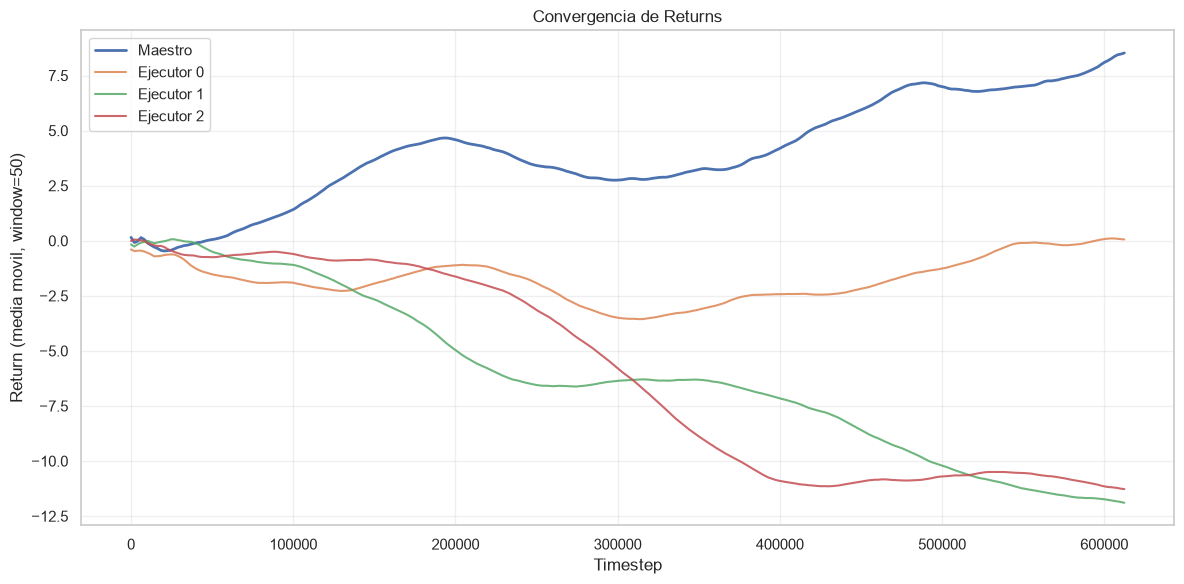

In [5]:
fig_returns = analyzer.plot_returns(window=50, save_path=CSV_PATH.parent / "plot_returns.png")
plt = __import__("matplotlib.pyplot", fromlist=["pyplot"])
plt.show()

## 6. Gráfico de Losses (policy / value / entropy)

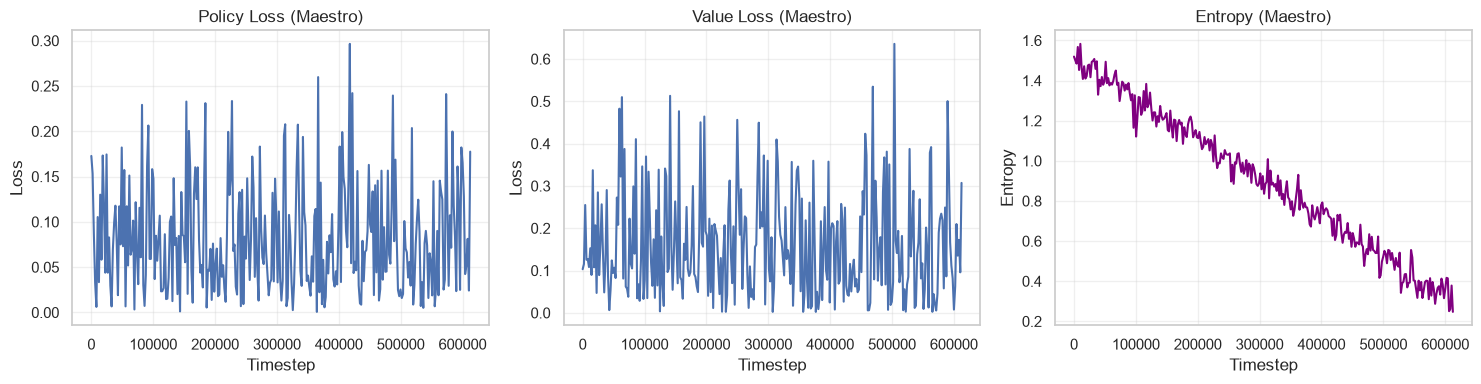

In [6]:
fig_losses = analyzer.plot_losses(save_path=CSV_PATH.parent / "plot_losses.png")
plt.show()

## 7. Estabilidad del entrenamiento

`std` del return del Maestro por bloques: debería decrecer si el entrenamiento
se está volviendo más estable (menos varianza entre episodios).

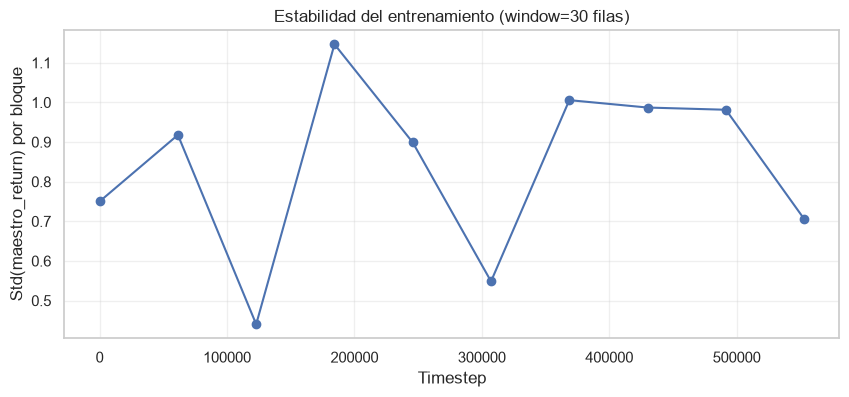

  step=       0.0  std=0.7501
  step=   61440.0  std=0.9179
  step=  122880.0  std=0.4403
  step=  184320.0  std=1.1466
  step=  245760.0  std=0.8989
  step=  307200.0  std=0.5485
  step=  368640.0  std=1.0056
  step=  430080.0  std=0.9870
  step=  491520.0  std=0.9814
  step=  552960.0  std=0.7059


In [7]:
window_stability = max(10, len(analyzer.df) // 10)  # ~10 bloques
steps_stab, stds = analyzer.compute_stability(window=window_stability)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps_stab, stds, marker="o")
ax.set_xlabel("Timestep")
ax.set_ylabel("Std(maestro_return) por bloque")
ax.set_title(f"Estabilidad del entrenamiento (window={window_stability} filas)")
ax.grid(True, alpha=0.3)
plt.show()

for s, v in zip(steps_stab, stds):
    print(f"  step={s:>10}  std={v:.4f}")

## 8. Factor de mejora vs. benchmark (TWAP/VWAP o baseline)

In [8]:
# Reemplazar baseline_return por el retorno real de TWAP/VWAP cuando Benjamin
# entregue los benchmarks (Sprint 5, tarea 2.3.4). Mientras tanto, 0.0 solo
# sirve para no dividir por cero, NO es un benchmark valido.
BASELINE_RETURN = 0.0

improvement = analyzer.compute_improvement_factor(baseline_return=BASELINE_RETURN)
print(f"Improvement factor (return final / baseline): {improvement:.4f}")
if BASELINE_RETURN == 0.0:
    print("⚠ BASELINE_RETURN sigue en placeholder (0.0): actualizar con TWAP/VWAP real antes de reportar esta cifra en la tesis.")

Improvement factor (return final / baseline): 8838164.3998
⚠ BASELINE_RETURN sigue en placeholder (0.0): actualizar con TWAP/VWAP real antes de reportar esta cifra en la tesis.


## 9. Test estadístico de tendencia

In [9]:
result = analyzer.statistical_test(alpha=0.05)
for k, v in result.items():
    print(f"{k}: {v}")

if result["significant"]:
    print("\n✓ Hay una tendencia POSITIVA/NEGATIVA significativa (p < 0.05) en el return del Maestro.")
else:
    print("\n⚠ No se detectó una tendencia lineal significativa (p >= 0.05). "
          "Esto no descarta convergencia: puede haber alcanzado un plateau, o la relación no ser lineal.")

slope: 0.025798072004803135
intercept: 0.9123690737174766
r_squared: 0.6947002629876142
p_value: 9.271992121055612e-79
std_err: 0.0009907032826161157
significant: True
alpha: 0.05

✓ Hay una tendencia POSITIVA/NEGATIVA significativa (p < 0.05) en el return del Maestro.


## 10. (Opcional) Generar reporte PDF

Requiere `pip install reportlab` (ya agregado a `requirements.txt`).

In [10]:
GENERAR_PDF = False  # cambiar a True cuando se quiera el PDF

if GENERAR_PDF:
    pdf_path = generate_report_pdf(analyzer, save_path=CSV_PATH.parent / "report_sprint4.pdf")
    print(f"PDF generado en: {pdf_path}")
else:
    print("Generación de PDF desactivada (GENERAR_PDF=False).")

Generación de PDF desactivada (GENERAR_PDF=False).


## 11. Próximo paso

Con los resultados de las celdas 7 y 9, completar `ANALYSIS_RESULTS.md` en la
raíz del repo (plantilla ya creada) con las cifras reales de este run.